<a href="https://colab.research.google.com/github/xolidausmonovaa-lang/ctf-game-hacking/blob/main/Latifa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()



Saving archive (2).zip to archive (2).zip


In [ ]:

import os
os.listdir()


['.config', 'archive (2).zip', 'sample_data']

In [ ]:
import zipfile

zipfile.ZipFile(list(uploaded.keys())[0]).extractall()

In [ ]:
import pandas as pd
import os

csv_file = [f for f in os.listdir() if f.endswith('.csv')][0]

df = pd.read_csv(csv_file)

df.head()

,Sl. No,Patient File No.,PCOS (Y/N),I beta-HCG(mIU/mL),II beta-HCG(mIU/mL),AMH(ng/mL)
0,1,10001,0,1.99,1.99,2.07
1,2,10002,0,60.80,1.99,1.53
2,3,10003,1,494.08,494.08,6.63
3,4,10004,0,1.99,1.99,1.22
4,5,10005,0,801.45,801.45,2.26


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3     I   beta-HCG(mIU/mL)  541 non-null    float64
 4   II    beta-HCG(mIU/mL)  541 non-null    float64
 5   AMH(ng/mL)              541 non-null    object 
dtypes: float64(2), int64(3), object(1)
memory usage: 25.5+ KB


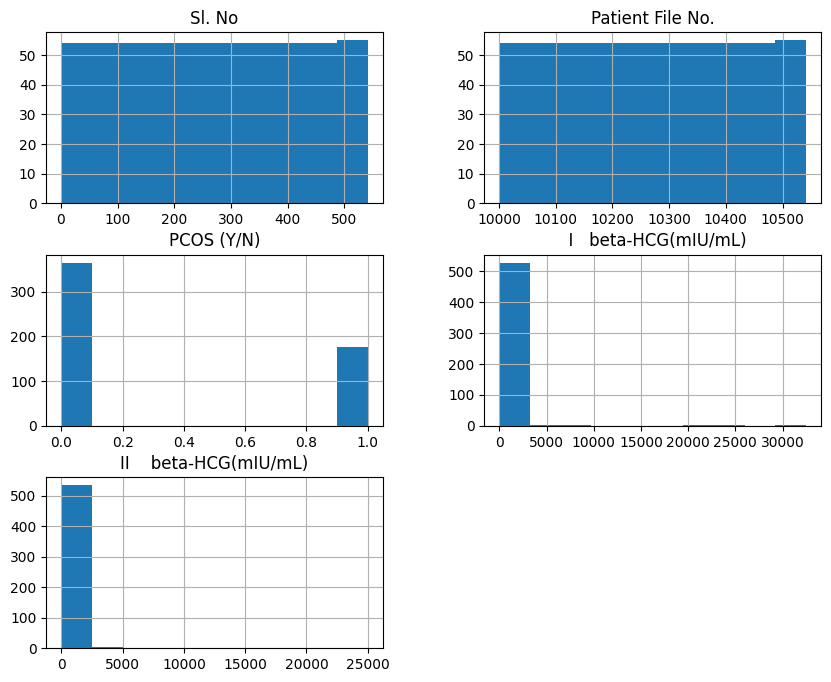

In [ ]:
import matplotlib.pyplot as plt

df_num = df.select_dtypes(include=['int64','float64'])
df_num.hist(figsize=(10,8))
plt.show()

In [ ]:
print(df.columns)

Index(['Sl. No', 'Patient File No.', 'PCOS (Y/N)', '  I   beta-HCG(mIU/mL)',
       'II    beta-HCG(mIU/mL)', 'AMH(ng/mL)'],
      dtype='object')


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

target_col = 'PCOS (Y/N)'

X = df.drop(columns=[target_col])
y = df[target_col]

# hammasini son qilamiz
X = X.apply(lambda x: pd.factorize(x)[0])

# train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# natija
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.6697247706422018


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df_num = df.select_dtypes(include=['int64','float64'])

X = df_num.iloc[:, :-1]
y = df_num.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))

MSE: 7953053.830914851


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# y ni kategoriya qilish
y_class = (y > y.mean())

X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2)

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree:", accuracy_score(y_test, y_pred_dt))

Decision Tree: 0.8623853211009175


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy: 0.8348623853211009


In [ ]:
from sklearn.svm import SVC

svm_model = SVC()
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.8348623853211009


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# regression uchun numeric dataset
df_num = df.select_dtypes(include=['int64','float64'])

X_reg = df_num.iloc[:, :-1]
y_reg = df_num.iloc[:, -1]

from sklearn.model_selection import train_test_split
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2)

rf_reg = RandomForestRegressor()
rf_reg.fit(Xr_train, yr_train)

y_pred_rf = rf_reg.predict(Xr_test)

print("Random Forest Regression MSE:", mean_squared_error(yr_test, y_pred_rf))

Random Forest Regression MSE: 6625178.68218267
